In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import classification_report, f1_score

import warnings
warnings.filterwarnings('ignore')


## 1: Load and Preprocess Data

In [2]:
# Load your fully feature-engineered dataset

df = pd.read_csv("feature_engineering/data_with_new_features.csv")
participant_col_name = 'participant'

# df = pd.read_csv("../data_cleaning/data/imputed_data.csv")
# participant_col_name = 'person'


In [3]:
# Exclude non-numeric columns
exclude_cols = [participant_col_name, 'timestamp', 'genre']
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

# Global normalization
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [4]:
# Encode other categorical columns (if any, excluding participant/timestamp/genre)
categorical_cols = df.select_dtypes(include=['object']).columns.difference([participant_col_name, 'timestamp', 'genre'])

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode the target variable 'genre'
genre_label_encoder = LabelEncoder()
df['genre_encoded'] = genre_label_encoder.fit_transform(df['genre'])


## 2. Train/Val/Test Split by Participants

In [5]:
# Split Clara for test only
test_df = df[df[participant_col_name] == 'clara'].copy()

# Combine Kenji and Aimen data
train_val_df = df[df[participant_col_name].isin(['kenji', 'aimen'])].copy()

# Stratified split into train (80%) and val (20%) from Kenji + Aimen
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    stratify=train_val_df['genre_encoded'],
    random_state=42
)

# Final test set is Clara
final_test_df = test_df.copy()

In [12]:
train_df

,timestamp,participant,heart_rate,x_coordinate,y_coordinate,pupil_diameter_mm,iris_diameter_mm,pupil_iris_ratio,head_displacement,head_velocity,...,pupil_iris_ratio_high_low,pupil_iris_ratio_high_normal,pupil_iris_ratio_low_high,pupil_iris_ratio_low_low,pupil_iris_ratio_low_normal,pupil_iris_ratio_normal_high,pupil_iris_ratio_normal_low,pupil_iris_ratio_normal_normal,genre,genre_encoded
7226,2025-06-12 09:29:27,aimen,0.341721,-0.910915,-0.242952,-0.504734,0.0,-0.504734,-0.439006,-0.434106,...,-0.707623,-1.318852,-0.820269,-0.997900,-1.211912,-1.247716,-1.141098,-2.218723,documentary,1
7764,2025-06-12 10:03:04,aimen,0.013393,-0.824738,-0.336031,0.240320,0.0,0.240320,-0.378483,-0.349816,...,-0.707623,-0.865501,-0.820269,-1.354056,-1.092830,-0.800110,-1.141098,-1.536330,comedy,0
8888,2025-06-12 10:25:55,aimen,0.493955,0.159161,-1.751275,1.452013,0.0,1.452013,-0.449296,-0.448437,...,-0.707623,0.041200,1.930356,0.375843,0.217069,-0.173462,0.441677,0.726068,horror,2
1686,2025-06-05 17:37:15,kenji,-1.732463,-0.995805,-0.556636,-0.429383,0.0,-0.429383,-0.418427,-0.426941,...,-0.707623,-0.593491,0.096606,-0.472147,-0.497422,-0.621068,-0.532338,-0.423503,documentary,1
450,2025-06-05 16:40:25,kenji,-0.933236,-0.820874,-0.964132,-0.220824,0.0,-0.220824,-0.335066,-0.368893,...,0.657811,-0.502821,0.096606,-0.353428,-0.735585,-0.531546,-0.775842,-0.670215,comedy,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,2025-06-05 17:29:59,kenji,-1.022039,-1.152821,-0.519991,1.945332,0.0,1.945332,-0.393087,-0.409296,...,-0.707623,-0.593491,0.096606,-0.472147,-0.497422,-0.621068,-0.532338,-0.423503,documentary,1
8382,2025-06-12 10:17:22,aimen,0.132400,-1.005523,-1.274885,-0.268267,0.0,-0.268267,-0.412312,-0.396929,...,-0.707623,0.041200,1.930356,0.375843,0.217069,-0.173462,0.441677,0.726068,horror,2
7641,2025-06-12 10:01:01,aimen,1.153955,-0.840739,-0.373157,-1.228355,0.0,-1.228355,0.294807,0.587861,...,-0.707623,-0.865501,-0.820269,-1.354056,-1.092830,-0.800110,-1.141098,-1.536330,comedy,0
2407,2025-06-05 18:15:35,kenji,-0.267214,-0.999008,-0.977129,1.651395,0.0,1.651395,1.401119,2.128602,...,-0.707623,-1.318852,-0.820269,-1.184458,-1.450076,-1.247716,-1.506354,-0.869684,horror,2


In [13]:
numeric_cols

['heart_rate',
 'x_coordinate',
 'y_coordinate',
 'pupil_diameter_mm',
 'iris_diameter_mm',
 'pupil_iris_ratio',
 'head_displacement',
 'head_velocity',
 'head_direction_change_rate',
 'head_stability',
 'centered_x',
 'centered_y',
 'td_heart_rate_mean',
 'td_heart_rate_std',
 'td_heart_rate_min',
 'td_heart_rate_max',
 'td_heart_rate_range',
 'td_heart_rate_slope',
 'td_heart_rate_mean_abs_change',
 'td_heart_rate_second_order_diff_mean',
 'td_centered_x_mean',
 'td_centered_x_std',
 'td_centered_x_min',
 'td_centered_x_max',
 'td_centered_x_range',
 'td_centered_x_slope',
 'td_centered_x_mean_abs_change',
 'td_centered_x_second_order_diff_mean',
 'td_centered_y_mean',
 'td_centered_y_std',
 'td_centered_y_min',
 'td_centered_y_max',
 'td_centered_y_range',
 'td_centered_y_slope',
 'td_centered_y_mean_abs_change',
 'td_centered_y_second_order_diff_mean',
 'td_pupil_diameter_mm_mean',
 'td_pupil_diameter_mm_std',
 'td_pupil_diameter_mm_min',
 'td_pupil_diameter_mm_max',
 'td_pupil_dia

In [6]:
# define features and labels
X_train = train_df[numeric_cols]
y_train = train_df['genre_encoded']

X_val = val_df[numeric_cols]
y_val = val_df['genre_encoded']

X_test = final_test_df[numeric_cols]
y_test = final_test_df['genre_encoded']

## 3. RFECV for Feature Selection

In [7]:
rf = RandomForestClassifier(n_estimators=75, max_depth=25, min_samples_split=15, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=rf, step=1, cv=cv, scoring='f1_weighted', n_jobs=-1)
rfecv.fit(X_train, y_train)

# Reduce features
X_train_sel = rfecv.transform(X_train)
X_val_sel = rfecv.transform(X_val)
X_test_sel = rfecv.transform(X_test)


In [8]:
feature_ranks = pd.DataFrame({
    'feature': X_train.columns,
    'rank': rfecv.ranking_
}).sort_values(by='rank')

print(feature_ranks)

                               feature  rank
82       iris_diameter_mm_fft_centroid     1
83        iris_diameter_mm_fft_entropy     2
86  iris_diameter_mm_fft_band_0.25_0.5     3
85  iris_diameter_mm_fft_band_0.1_0.25     4
77    pupil_diameter_mm_fft_band_0_0.1     5
..                                 ...   ...
1                         x_coordinate   120
63                       iris_kurtosis   121
49           td_iris_diameter_mm_slope   122
62                           iris_skew   123
0                           heart_rate   124

[124 rows x 2 columns]


## 4. Train and Evaluate Final Random Forest

In [9]:
rf_final = RandomForestClassifier(n_estimators=75, max_depth=25, min_samples_split=15, random_state=42)
rf_final.fit(X_train_sel, y_train)

# Validation
val_preds = rf_final.predict(X_val_sel)
print("Validation Report:\n", classification_report(y_val, val_preds))

# Test
test_preds = rf_final.predict(X_test_sel)
print("Test Report:\n", classification_report(y_test, test_preds))

Validation Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       323
           1       1.00      1.00      1.00       294
           2       1.00      1.00      1.00       427

    accuracy                           1.00      1044
   macro avg       1.00      1.00      1.00      1044
weighted avg       1.00      1.00      1.00      1044

Test Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1336
           1       0.00      0.00      0.00      1556
           2       0.44      1.00      0.61      1212

    accuracy                           0.62      4104
   macro avg       0.48      0.67      0.54      4104
weighted avg       0.45      0.62      0.51      4104



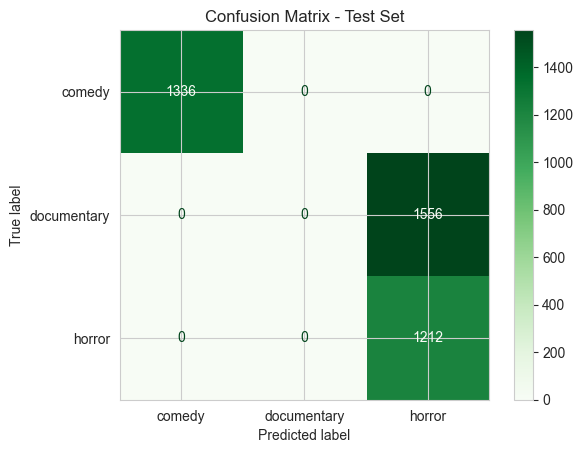

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Test confusion matrix
test_cm = confusion_matrix(y_test, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=genre_label_encoder.classes_)
test_disp.plot(cmap='Greens')
plt.title("Confusion Matrix - Test Set")
plt.show()


In [11]:
# RF works better with raw features